In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

reading data .csv file

In [3]:
df = pd.read_csv("/content/ToyotaCorolla - MLR.csv")


In [4]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


checking columns

In [6]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

checking missing values

In [7]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [8]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


correlation matrix

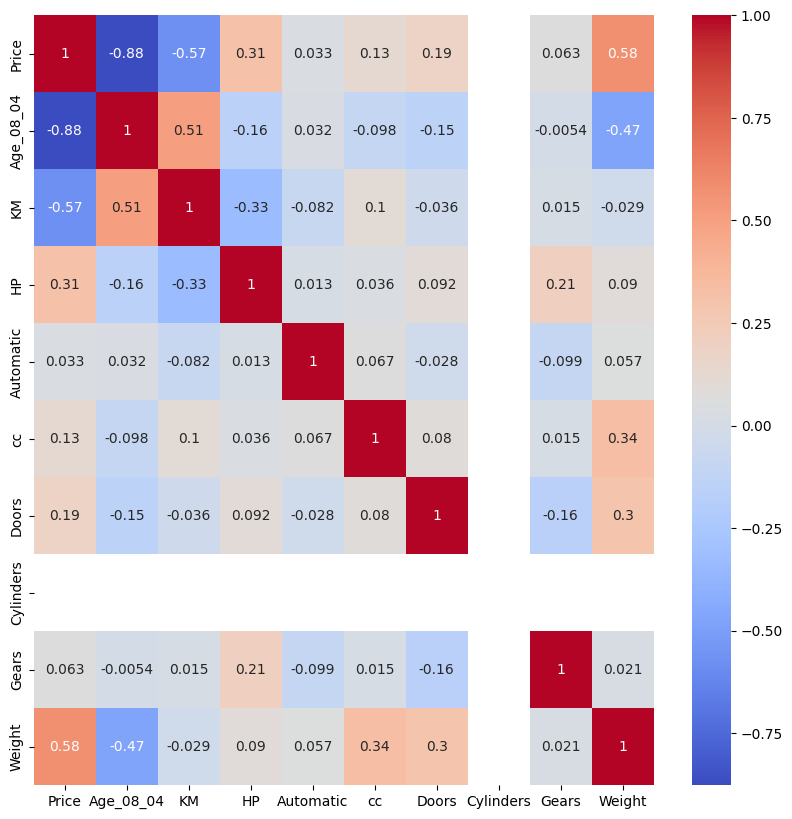

In [9]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap="coolwarm")
plt.show()

histoplot

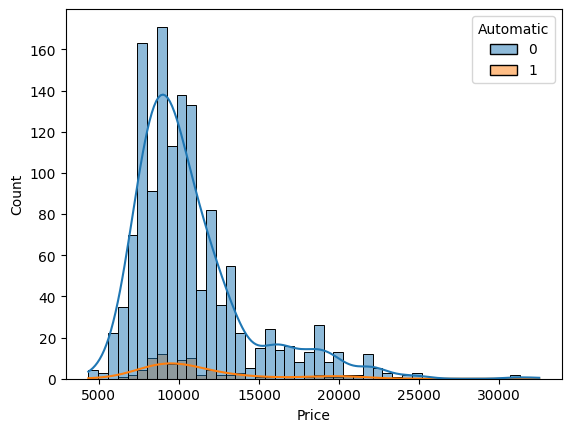

In [10]:
sns.histplot(data=df, x="Price", kde=True, hue='Automatic')
plt.show()

boxplot

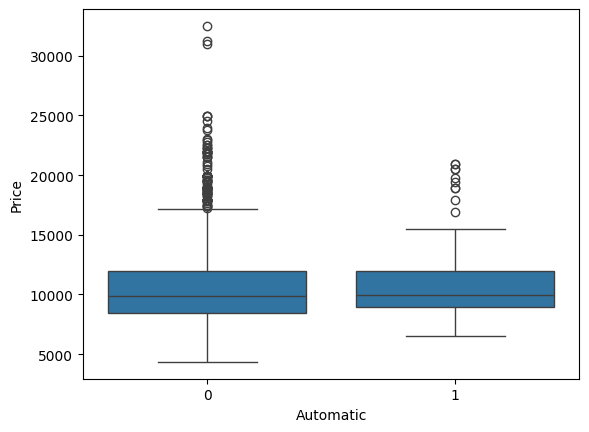

In [11]:
sns.boxplot(data=df, x='Automatic', y='Price')
plt.show()

pairplot

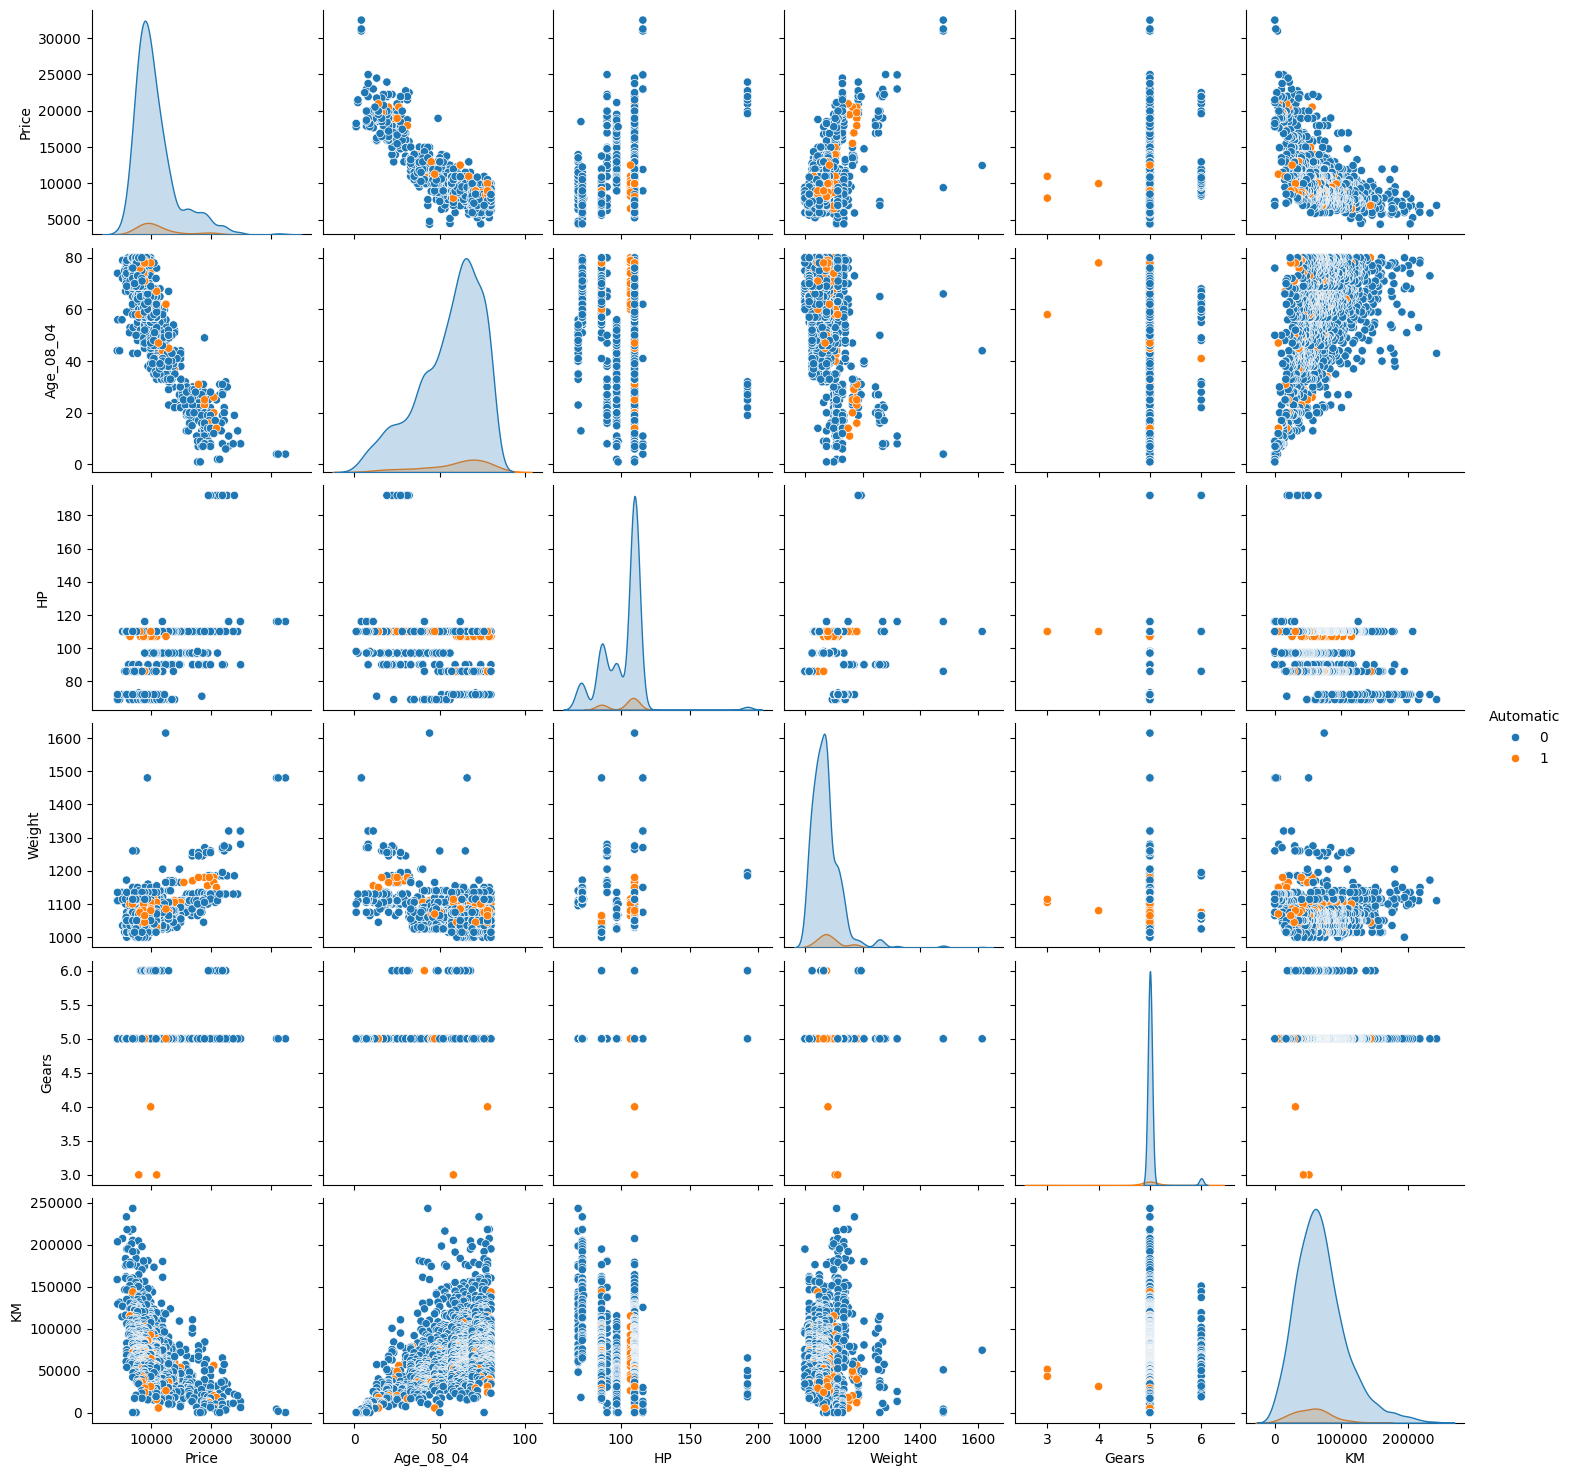

In [12]:
sns.pairplot(df[['Price','Age_08_04','HP','Weight','Automatic','Gears','KM']], hue='Automatic')
plt.show()

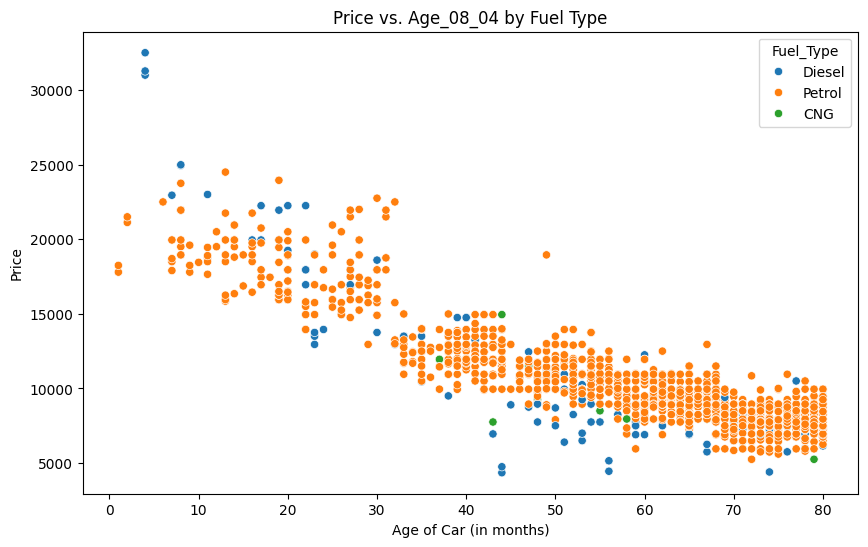

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age_08_04', y='Price', hue='Fuel_Type')
plt.title('Price vs. Age_08_04 by Fuel Type')
plt.xlabel('Age of Car (in months)')
plt.ylabel('Price')
plt.show()

Data preprocessing

In [14]:
encoder = LabelEncoder()
df["Fuel_Type"] = encoder.fit_transform(df["Fuel_Type"])

In [15]:
x = df.drop(columns=['Price'], axis=1)
y = df['Price']


splitting dataset into (70-30)

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.30,random_state=30)

### Splitting Data into Training and Test Sets

To evaluate how well your machine learning model generalizes to new, unseen data, it's essential to split your dataset into two subsets:

1.  **Training Set:** Used to train the machine learning model.
2.  **Test Set:** Used to evaluate the performance of the trained model.

The `train_test_split` function from `sklearn.model_selection` is commonly used for this purpose. It shuffles the data randomly and then divides it according to the specified `test_size`.

**Key parameters:**
*   `test_size`: The proportion of the dataset to include in the test split (e.g., `0.20` for 20% test data).
*   `random_state`: A seed for the random number generator. Using a fixed `random_state` ensures that your split is reproducible.

In [17]:
# Assuming 'x' contains your features and 'y' contains your target variable
# x and y are already defined in this notebook from earlier steps.

# Split the data with a 80% training set and 20% test set, and a fixed random state for reproducibility.
X_train_example, X_test_example, y_train_example, y_test_example = train_test_split(x, y, test_size=0.20, random_state=42)

print(f"Shape of training features: {X_train_example.shape}")
print(f"Shape of testing features: {X_test_example.shape}")
print(f"Shape of training target: {y_train_example.shape}")
print(f"Shape of testing target: {y_test_example.shape}")

Shape of training features: (1148, 10)
Shape of testing features: (288, 10)
Shape of training target: (1148,)
Shape of testing target: (288,)


standardization

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

build three linear regression

 first linear regression

In [19]:
lr1 = LinearRegression()
lr1.fit(X_train_scaled, y_train)
pred1 = lr1.predict(X_test_scaled)

second linear regression

In [20]:
features = ["Age_08_04","KM","HP","Weight","Automatic"]

X2 = df[features]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2,y,test_size=0.30,random_state=30)

scaler2 = StandardScaler()

X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

lr2 = LinearRegression()

lr2.fit(X_train2, y_train2)

pred2 = lr2.predict(X_test2)

third linear regression

In [21]:
features = ["Age_08_04","KM","Weight"]

X3 = df[features]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3,y,test_size=0.30,random_state=30)

scaler3 = StandardScaler()

X_train3 = scaler3.fit_transform(X_train3)
X_test3 = scaler3.transform(X_test3)

lr3 = LinearRegression()

lr3.fit(X_train3, y_train3)

pred3 = lr3.predict(X_test3)

Interpretation of Coefficients

In [22]:
oef = pd.DataFrame({"Feature":x.columns,"Coefficient":lr1.coef_})
print(oef)

     Feature  Coefficient
0  Age_08_04 -2312.629625
1         KM  -688.341322
2  Fuel_Type   217.839594
3         HP   375.279301
4  Automatic    59.579245
5         cc   -25.600245
6      Doors   -43.590714
7  Cylinders     0.000000
8      Gears   104.327098
9     Weight  1123.322966


model evaluation

In [23]:
def evaluate(actual,pred):

    print("MAE :",mean_absolute_error(actual,pred))
    print("MSE :",mean_squared_error(actual,pred))
    print("RMSE :",np.sqrt(mean_squared_error(actual,pred)))
    print("R2 :",r2_score(actual,pred))

In [24]:
evaluate(y_test,pred1)
evaluate(y_test2,pred2)
evaluate(y_test3,pred3)

MAE : 998.2022018512428
MSE : 2008631.3999033577
RMSE : 1417.2619376471512
R2 : 0.8403399986161368
MAE : 1030.1674021265958
MSE : 2053946.39715833
RMSE : 1433.1595853771241
R2 : 0.8367380472950599
MAE : 1044.2089007326165
MSE : 2196676.446155938
RMSE : 1482.1189041895182
R2 : 0.8253928697669313


ridge regresssion

In [25]:
ridge = Ridge(alpha=0.1)
ridge.fit(X_train_scaled, y_train)
pred_ridge = ridge.predict(X_test_scaled)
evaluate(y_test,pred_ridge)

MAE : 998.1814799181294
MSE : 2008564.2004134266
RMSE : 1417.2382299435146
R2 : 0.8403453400992262


 Lasso regression

In [26]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
pred_lasso = lasso.predict(X_test_scaled)
evaluate(y_test,pred_lasso)

MAE : 998.2116548083609
MSE : 2008540.0999358774
RMSE : 1417.2297272975463
R2 : 0.8403472557728929


What is Normalization & Standardization and how is it helpful?

Normalization and Standardization are both techniques used in data preprocessing to transform numerical features in a dataset to a common scale. They are particularly important for machine learning algorithms that are sensitive to the scale of the input features.
> Normalization (Min-Max Scaling)
What it is: Normalization scales features to a fixed range, typically between 0 and 1.
> Standardization (Z-score Normalization)
What it is: Standardization transforms data to have a mean of 0 and a standard deviation of 1.


What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity occurs when independent variables in a multiple regression model are highly correlated with each other. This can cause problems for the regression model, such as unstable coefficient estimates, inflated standard errors, and difficulty in interpreting the individual effect of each predictor. Here are several techniques to address multicollinearity:
1. Remove Highly Correlated Predictors.
2. Combine correlated predictiors.
3. Principle component Analysis.
4. Ridge regression and lasso Regression(Regularization Technique)